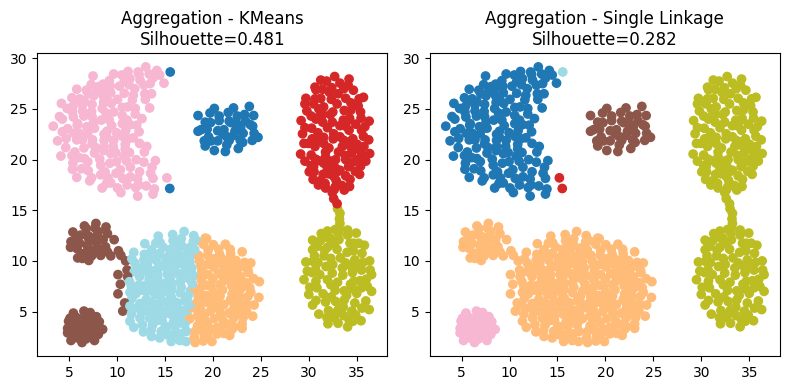


Dataset: Aggregation
Silhouette KMeans: 0.481
Silhouette Single: 0.282


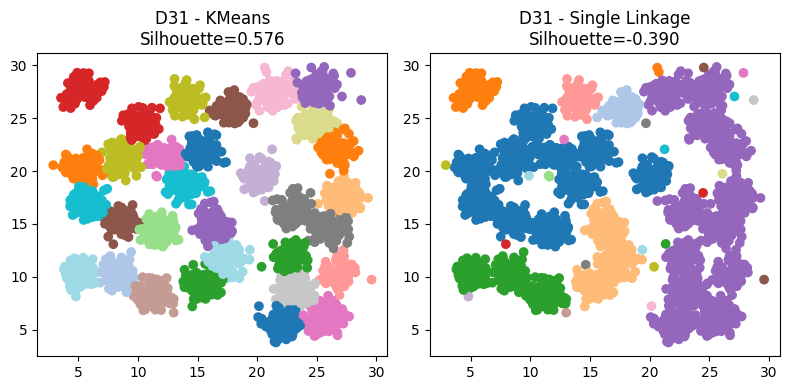


Dataset: D31
Silhouette KMeans: 0.576
Silhouette Single: -0.39


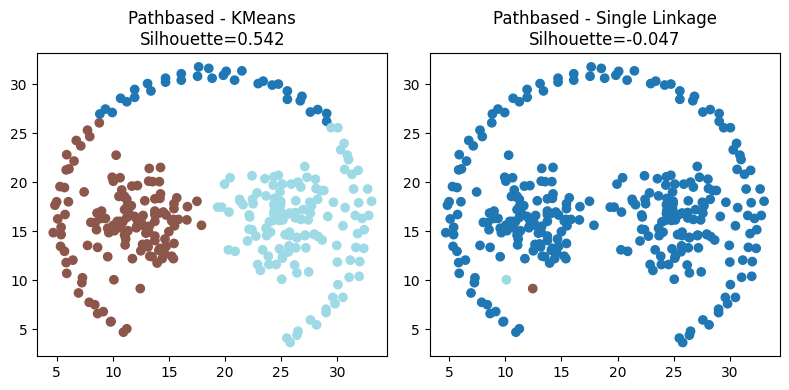


Dataset: Pathbased
Silhouette KMeans: 0.542
Silhouette Single: -0.047


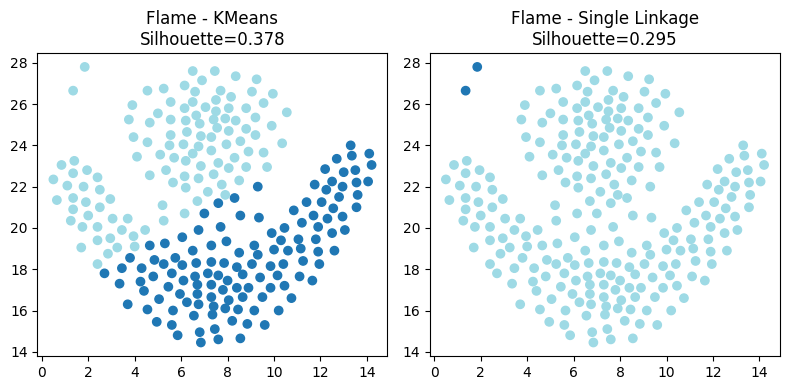


Dataset: Flame
Silhouette KMeans: 0.378
Silhouette Single: 0.295


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

urls = {
    "Aggregation": "http://cs.joensuu.fi/sipu/datasets/Aggregation.txt",
    "D31": "http://cs.joensuu.fi/sipu/datasets/D31.txt",
    "Pathbased": "http://cs.joensuu.fi/sipu/datasets/pathbased.txt",
    "Flame": "http://cs.joensuu.fi/sipu/datasets/flame.txt"
}

# número de clusters reais de cada dataset
k_reais = {
    "Aggregation": 7,
    "D31": 31,
    "Pathbased": 3,
    "Flame": 2
}

for nome, url in urls.items():

    dados = pd.read_csv(
        url,
        sep="\t",
        header=None
    )

    X = dados.iloc[:, :2]

    k = k_reais[nome]

    # K-Means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_kmeans = kmeans.fit_predict(X)

    sil_kmeans = silhouette_score(
        X,
        labels_kmeans
    )

    # Single Linkage
    single = AgglomerativeClustering(
        n_clusters=k,
        linkage="single"
    )

    labels_single = single.fit_predict(X)

    sil_single = silhouette_score(
        X,
        labels_single
    )

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(8,4)
    )

    ax[0].scatter(
        X.iloc[:,0],
        X.iloc[:,1],
        c=labels_kmeans,
        cmap="tab20"
    )

    ax[0].set_title(
        f"{nome} - KMeans\nSilhouette={sil_kmeans:.3f}"
    )

    ax[1].scatter(
        X.iloc[:,0],
        X.iloc[:,1],
        c=labels_single,
        cmap="tab20"
    )

    ax[1].set_title(
        f"{nome} - Single Linkage\nSilhouette={sil_single:.3f}"
    )

    plt.tight_layout()
    plt.show()

    print("\nDataset:", nome)
    print("Silhouette KMeans:", round(sil_kmeans,3))
    print("Silhouette Single:", round(sil_single,3))